In [1]:
import os

In [2]:
os.getcwd()

os.chdir("C:\\Users\\ADMIN\\sevenmentors\\Blinkit Data Analysis\\Data")

In [3]:
os.listdir()

['blinkit_cleaned_data.csv',
 'blinkit_customers.csv',
 'blinkit_customer_feedback.csv',
 'blinkit_delivery_performance.csv',
 'blinkit_final_dashboard_data.csv',
 'blinkit_inventory.csv',
 'blinkit_inventoryNew.csv',
 'blinkit_marketing_performance.csv',
 'blinkit_orders.csv',
 'blinkit_order_items.csv',
 'blinkit_products.csv',
 'Category_Icons.xlsx',
 'Rating_Icon.xlsx']

In [4]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [5]:
customers = pd.read_csv("blinkit_customers.csv")

orders = pd.read_csv("blinkit_orders.csv")

order_items = pd.read_csv("blinkit_order_items.csv")

products = pd.read_csv("blinkit_products.csv")

inventory = pd.read_csv("blinkit_inventory.csv")

delivery = pd.read_csv("blinkit_delivery_performance.csv")

feedback = pd.read_csv("blinkit_customer_feedback.csv")

marketing = pd.read_csv("blinkit_marketing_performance.csv")

In [6]:
tables_list = [customers, orders, order_items, products, inventory, delivery, feedback, marketing]


tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "inventory": inventory,
    "delivery": delivery,
    "feedback": feedback,
    "marketing": marketing
}

for name, table in tables.items():
    print(f"\n{name.upper()} COLUMNS")
    print(table.columns.tolist())
    print("-" * 50)


CUSTOMERS COLUMNS
['customer_id', 'customer_name', 'email', 'phone', 'address', 'area', 'pincode', 'registration_date', 'customer_segment', 'total_orders', 'avg_order_value']
--------------------------------------------------

ORDERS COLUMNS
['order_id', 'customer_id', 'order_date', 'promised_delivery_time', 'actual_delivery_time', 'delivery_status', 'order_total', 'payment_method', 'delivery_partner_id', 'store_id']
--------------------------------------------------

ORDER_ITEMS COLUMNS
['order_id', 'product_id', 'quantity', 'unit_price']
--------------------------------------------------

PRODUCTS COLUMNS
['product_id', 'product_name', 'category', 'brand', 'price', 'mrp', 'margin_percentage', 'shelf_life_days', 'min_stock_level', 'max_stock_level']
--------------------------------------------------

INVENTORY COLUMNS
['product_id', 'date', 'stock_received', 'damaged_stock']
--------------------------------------------------

DELIVERY COLUMNS
['order_id', 'delivery_partner_id', 'prom

In [7]:
# preview dataset

for table_name,table in tables.items():
    print(table_name)
    print(table.head())
    print("-" * 50)

customers
   customer_id  customer_name                     email         phone  \
0     97475543  Niharika Nagi    ektataneja@example.org  912987579691   
1     22077605   Megha Sachar      vedant45@example.com  915123179717   
2     47822591     Hema Bahri     samiazaan@example.com  910034076149   
3     79726146     Zaitra Vig     ishanvi87@example.org  916264232390   
4     57102800   Januja Verma  atideshpande@example.org  917293526596   

                               address          area  pincode  \
0  23, Nayar Path, Bihar Sharif-154625         Udupi   321865   
1  51/302, Buch Chowk\nSrinagar-570271       Aligarh   149394   
2   941\nAnne Street, Darbhanga 186125     Begusarai   621411   
3       43/94, Ghosh, Alappuzha 635655     Kozhikode   826054   
4             06\nOm, Ambarnath 477463  Ichalkaranji   730539   

  registration_date customer_segment  total_orders  avg_order_value  
0        2023-05-13          Premium            13           451.92  
1        2024-06-18 

In [8]:
# TAble shape 

for table_name, table in tables.items():
    print(table_name)
    print(table.shape)
    print("-" * 50)

customers
(2500, 11)
--------------------------------------------------
orders
(5000, 10)
--------------------------------------------------
order_items
(5000, 4)
--------------------------------------------------
products
(268, 10)
--------------------------------------------------
inventory
(75172, 4)
--------------------------------------------------
delivery
(5000, 8)
--------------------------------------------------
feedback
(5000, 8)
--------------------------------------------------
marketing
(5400, 11)
--------------------------------------------------


In [9]:
# Finding null values
for t_name,table in tables.items():
    print(t_name)
    print(table.isnull().sum())
    print("-" * 50)

customers
customer_id          0
customer_name        0
email                0
phone                0
address              0
area                 0
pincode              0
registration_date    0
customer_segment     0
total_orders         0
avg_order_value      0
dtype: int64
--------------------------------------------------
orders
order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64
--------------------------------------------------
order_items
order_id      0
product_id    0
quantity      0
unit_price    0
dtype: int64
--------------------------------------------------
products
product_id           0
product_name         0
category             0
brand                0
price                0
mrp                  0
margin_percentage    0
shelf_life_d

In [10]:
#Remove duplicates

for table in tables.values():
    print(table.drop_duplicates(inplace=True))



None
None
None
None
None
None
None
None


In [11]:
# handling missing values

delivery['reasons_if_delayed'] = delivery['reasons_if_delayed'].fillna("Unknown")

In [12]:
# Check Data types

for t_name,table in tables.items():
    print(t_name)
    print(table.info())
    print("*" * 50)

customers
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   int64  
 1   customer_name      2500 non-null   object 
 2   email              2500 non-null   object 
 3   phone              2500 non-null   int64  
 4   address            2500 non-null   object 
 5   area               2500 non-null   object 
 6   pincode            2500 non-null   int64  
 7   registration_date  2500 non-null   object 
 8   customer_segment   2500 non-null   object 
 9   total_orders       2500 non-null   int64  
 10  avg_order_value    2500 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 175.8+ KB
None
**************************************************
orders
<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              

In [13]:
# Describe Tables

for t_name,table in tables.items():
    print(t_name)
    print(table.describe())
    print("*" * 50)

customers
        customer_id         phone        pincode  total_orders  \
count  2.500000e+03  2.500000e+03    2500.000000   2500.000000   
mean   4.989961e+07  9.150532e+11  497653.183200     10.491600   
std    2.919266e+07  2.882835e+09  281167.293249      5.805533   
min    3.181300e+04  9.100132e+11     666.000000      1.000000   
25%    2.402443e+07  9.125946e+11  257079.750000      6.000000   
50%    5.000044e+07  9.150236e+11  498662.000000     10.000000   
75%    7.595459e+07  9.176256e+11  740668.000000     16.000000   
max    9.989390e+07  9.199988e+11  999631.000000     20.000000   

       avg_order_value  
count      2500.000000  
mean       1102.375836  
std         523.043183  
min         200.430000  
25%         631.817500  
50%        1118.650000  
75%        1565.400000  
max        1999.830000  
**************************************************
orders
           order_id   customer_id  order_total  delivery_partner_id  \
count  5.000000e+03  5.000000e+03   5000.

In [14]:
# Convert date columns

orders['order_date'] = pd.to_datetime(orders['order_date'])

feedback['feedback_date'] = pd.to_datetime(feedback['feedback_date'])

customers['registration_date'] = pd.to_datetime(customers['registration_date'])

delivery['actual_time']= pd.to_datetime(delivery['actual_time'])

delivery['promised_time'] = pd.to_datetime(delivery['promised_time'])

orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])

orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])


In [15]:
# Merge tables
# customers and orders
orders_customers = pd.merge(orders,customers,on='customer_id',how='left')


In [16]:
#merge order_items and order_customer
sales_data = pd.merge(orders_customers,order_items,on='order_id',how='left')

In [17]:
# merge products
sales_data = pd.merge(sales_data,products,on='product_id',how='left')

In [18]:
# merge delivery
sales_data = pd.merge(sales_data,delivery,on='order_id',how='left')

In [19]:
# merge feedback

sales_data = pd.merge(sales_data,feedback,on='order_id',how='left')

In [20]:
# final sales data

sales_data.head()

# sales_data.to_csv("blinkit_cleaned_data.csv", index=False)

,order_id,customer_id_x,order_date,promised_delivery_time,actual_delivery_time,delivery_status_x,order_total,payment_method,delivery_partner_id_x,store_id,...,distance_km,delivery_status_y,reasons_if_delayed,feedback_id,customer_id_y,rating,feedback_text,feedback_category,sentiment,feedback_date
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,0.96,On Time,Unknown,2234710,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,0.98,On Time,Traffic,5450964,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,3.83,On Time,Traffic,482108,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,2.76,On Time,Unknown,4823104,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,2.63,On Time,Traffic,3537464,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


In [21]:
# Checking new table column names

sales_data.columns

Index(['order_id', 'customer_id_x', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status_x', 'order_total',
       'payment_method', 'delivery_partner_id_x', 'store_id', 'customer_name',
       'email', 'phone', 'address', 'area', 'pincode', 'registration_date',
       'customer_segment', 'total_orders', 'avg_order_value', 'product_id',
       'quantity', 'unit_price', 'product_name', 'category', 'brand', 'price',
       'mrp', 'margin_percentage', 'shelf_life_days', 'min_stock_level',
       'max_stock_level', 'delivery_partner_id_y', 'promised_time',
       'actual_time', 'delivery_time_minutes', 'distance_km',
       'delivery_status_y', 'reasons_if_delayed', 'feedback_id',
       'customer_id_y', 'rating', 'feedback_text', 'feedback_category',
       'sentiment', 'feedback_date'],
      dtype='object')

In [22]:
# renaming order_total column to total_revenue

sales_data = sales_data.rename(columns={'order_total':'total_amount'})

In [23]:
# Checking for columns with same values

[col for col in sales_data.columns if '_x' in col or '_y' in col]

['customer_id_x',
 'delivery_status_x',
 'delivery_partner_id_x',
 'delivery_partner_id_y',
 'delivery_status_y',
 'customer_id_y']

In [24]:
# Droping customer_id_y as it contains same values as customerid_x and renaming customer_id_x

sales_data.drop('customer_id_y',axis=1,inplace=True)

sales_data = sales_data.rename(columns={'customer_id_x':'customer_id'})

In [25]:
# Same for delivery status

sales_data.drop('delivery_status_y',axis=1,inplace=True)

sales_data = sales_data.rename(columns={'delivery_status_x':'delivery_status'})

In [26]:
# Same for delivery partner

sales_data.drop('delivery_partner_id_y',axis=1,inplace=True)

sales_data = sales_data.rename(columns={'delivery_partner_id_x':'delivery_partner'})

In [27]:
# Create delay minutes column

sales_data['delay_minutes'] = (sales_data['actual_delivery_time'] - sales_data['promised_delivery_time']).dt.total_seconds()/60

In [28]:
print(sales_data.info())
print('*'*50)
print(sales_data.shape)
print('*'*50)
print(sales_data.head())
print('*'*50)
print(sales_data.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                5000 non-null   int64         
 1   customer_id             5000 non-null   int64         
 2   order_date              5000 non-null   datetime64[ns]
 3   promised_delivery_time  5000 non-null   datetime64[ns]
 4   actual_delivery_time    5000 non-null   datetime64[ns]
 5   delivery_status         5000 non-null   object        
 6   total_amount            5000 non-null   float64       
 7   payment_method          5000 non-null   object        
 8   delivery_partner        5000 non-null   int64         
 9   store_id                5000 non-null   int64         
 10  customer_name           5000 non-null   object        
 11  email                   5000 non-null   object        
 12  phone                   5000 non-null   int64   

In [29]:
# FInd total revenue
total_revenue = sales_data['total_amount'].sum()
print(total_revenue)

11009308.5


In [30]:
# TOtal orders

total_orders = sales_data['order_id'].nunique()
print(total_orders)

5000


In [31]:
# Total customers

total_customers = sales_data['customer_id'].nunique()
print(total_customers)

2172


In [32]:
#Average order value

average_order_value = total_revenue/total_orders
print(average_order_value)

2201.8617


In [33]:
# Top selling categories

category_sales = sales_data.groupby('category')['total_amount'].sum()
print(category_sales.sort_values(ascending=False))

category
Dairy & Breakfast        1244368.69
Household Care           1136440.47
Pet Care                 1125103.80
Fruits & Vegetables      1085102.76
Pharmacy                 1055811.97
Snacks & Munchies        1043581.94
Grocery & Staples        1005494.87
Personal Care            1003163.40
Cold Drinks & Juices      828002.23
Instant & Frozen Food     741183.31
Baby Care                 741055.06
Name: total_amount, dtype: float64


In [34]:
# Top products

top_products = sales_data.groupby('product_name')['total_amount'].sum()
print(top_products.sort_values(ascending=False))

product_name
Pet Treats           525666.31
Toilet Cleaner       434588.60
Lotion               434235.77
Dish Soap            420875.06
Cough Syrup          407824.64
Vitamins             406790.72
Baby Wipes           394356.96
Cat Food             325338.65
Pulses               311964.65
Bread                297989.26
Detergent            280976.81
Dog Food             274098.84
Potatoes             267296.03
Eggs                 263451.48
Orange Juice         256138.12
Biscuits             254808.12
Cola                 253035.54
Baby Food            249322.68
Pain Reliever        241196.61
Onions               240874.55
Frozen Biryani       232950.61
Wheat Flour          227639.70
Sugar                222641.59
Popcorn              202142.34
Soap                 198047.88
Cheese               196609.58
Toothpaste           194910.69
Carrots              192410.05
Frozen Pizza         180699.57
Shampoo              175969.06
Chips                174398.30
Nuts                 16261

In [35]:
# Customer repeat purchases

repeat_purchases = sales_data.groupby('customer_id')['order_id'].nunique()

repeat_purchases = repeat_purchases[repeat_purchases > 1]
print(repeat_purchases)

customer_id
31813       2
61020       3
119099      4
188838      2
191616      2
           ..
99729547    3
99734256    3
99772709    3
99824171    2
99893898    4
Name: order_id, Length: 1492, dtype: int64


In [36]:
# Top Repeat Customers
top_customers = sales_data.groupby('customer_id')['order_id'].nunique().sort_values(ascending=False)
print(top_customers.head())

customer_id
77869660    9
17805991    8
8791577     8
12832151    7
21701991    7
Name: order_id, dtype: int64


In [37]:
# Monthly sales Trend

sales_data['month'] = sales_data['order_date'].dt.month_name()

monthly_sales = sales_data.groupby('month')['total_amount'].sum()
print(monthly_sales)

month
April        1093099.52
August       1169666.92
December      615709.03
February      545090.11
January       560423.56
July         1140751.89
June         1044302.51
March         816060.81
May          1182377.15
November      635941.39
October      1116072.77
September    1089812.84
Name: total_amount, dtype: float64


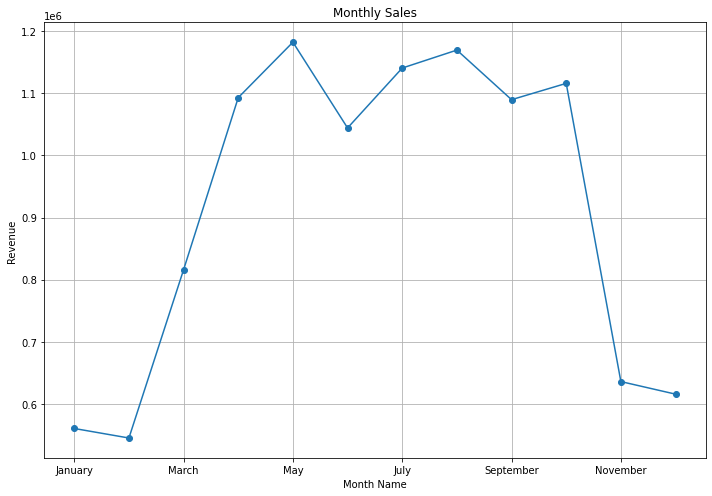

In [38]:
# Monthly sales plot

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales.plot(kind='line',marker='o',figsize=(10,7))

plt.title("Monthly Sales")
plt.xlabel("Month Name")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()

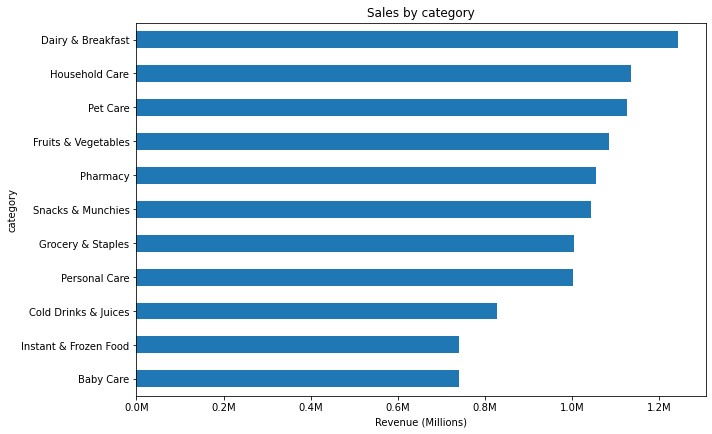

In [39]:
# Plot top categories

category_sales.sort_values().plot(kind='barh',figsize=(10,7))
plt.title("Sales by category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()


ax = category_sales.sort_values().plot(kind='barh', figsize=(10, 6))

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.xlabel("Revenue (Millions)")
plt.show()


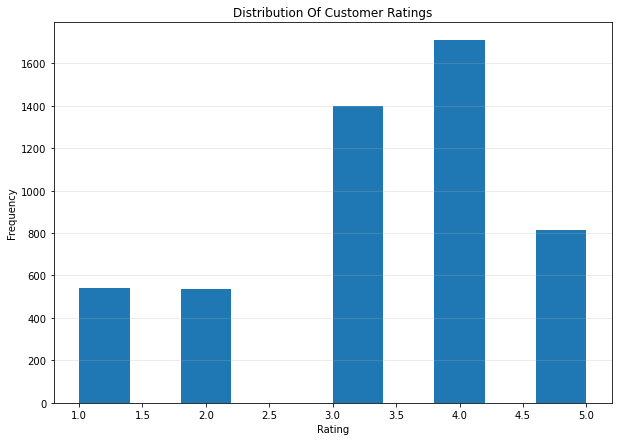

In [40]:
# Customer rating distribution

sales_data['rating'].plot(kind='hist',bins=10,figsize=(10,7))

plt.title("Distribution Of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.grid(axis='y',alpha=0.3)
plt.show()

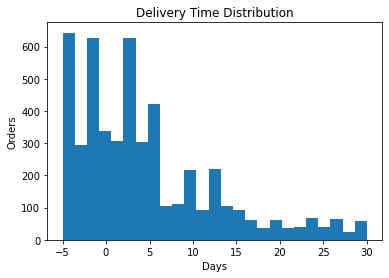

In [41]:
# Distribution of Delivery Time

sales_data['delivery_time_minutes'].plot(kind='hist',bins=25)

plt.title("Delivery Time Distribution")
plt.xlabel("Days")
plt.ylabel("Orders")
plt.show()

In [42]:
# Actual delivery time
sales_data['actual_delivery_duration'] = (
    sales_data['actual_delivery_time'] -
    sales_data['order_date']
).dt.total_seconds()/60


# Delayed time
sales_data['delay_minutes'] = (
    sales_data['actual_delivery_time'] -
    sales_data['promised_delivery_time']
).dt.total_seconds()/60

#Average delay
sales_data['delay_minutes'].mean()

#Delayed orders
delayed_orders = sales_data[
    sales_data['delay_minutes'] > 0
]

len(delayed_orders)

# ON time delivery
on_time_pct = (
    (sales_data['delay_minutes'] <= 0).sum()
    / len(sales_data)
) * 100

print(on_time_pct)

38.04


In [43]:
(
sales_data['actual_delivery_time']
==
sales_data['actual_time']
).all()

sales_data[['delay_minutes']].describe()


sales_data['delivery_status'].value_counts()

On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: delivery_status, dtype: int64

In [44]:
delivery_status_pct = (
    sales_data['delivery_status']
    .value_counts(normalize=True) * 100
).round(2)

print(delivery_status_pct)

On Time                  69.40
Slightly Delayed         20.74
Significantly Delayed     9.86
Name: delivery_status, dtype: float64


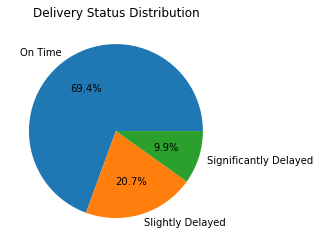

In [45]:
#Delivery Status Distribution

delivery_status_percentage = sales_data['delivery_status'].value_counts(normalize=True)*100

delivery_status_percentage.plot(kind='pie',autopct='%1.1f%%',ylabel='')

plt.title("Delivery Status Distribution")
plt.show()

In [46]:
sales_data.to_csv(
    "blinkit_final_dashboard_data.csv",
    index=False
)

In [47]:
import csv

sales_data.to_csv(
    "blinkit_final.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL
)